# 03 — Exploratory Data Analysis: Patient-Level Asthma Data

**Input:** `data/processed/asthma_cleaned.csv` (output of `01_Data_Cleaning.ipynb`)
**Goal:** understand the patient population, spot patterns linked to an asthma diagnosis, and
surface the features most worth carrying into the Machine Learning notebook (`04_Machine_Learning.ipynb`).

Sections:
1. Setup & load
2. Target variable (Diagnosis) — class balance
3. Demographics (age, gender, ethnicity, education)
4. Lifestyle factors (BMI, smoking, activity, diet, sleep)
5. Environmental & allergy factors
6. Medical history & risk factors
7. Clinical measurements (lung function)
8. Symptoms
9. Correlation analysis
10. Statistical tests: which features actually differ by diagnosis?
11. Key insights summary


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("darkgrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 60)

df = pd.read_csv("../data/processed/asthma_cleaned.csv")
print("Shape:", df.shape)
df.head()


Shape: (2392, 50)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,PhysicalActivity,DietQuality,SleepQuality,PollutionExposure,PollenExposure,DustExposure,PetAllergy,FamilyHistoryAsthma,HistoryOfAllergies,Eczema,HayFever,GastroesophagealReflux,LungFunctionFEV1,LungFunctionFVC,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis,Gender_Label,Ethnicity_Label,EducationLevel_Label,Smoking_Label,PetAllergy_Label,FamilyHistoryAsthma_Label,HistoryOfAllergies_Label,Eczema_Label,HayFever_Label,GastroesophagealReflux_Label,Wheezing_Label,ShortnessOfBreath_Label,ChestTightness_Label,Coughing_Label,NighttimeSymptoms_Label,ExerciseInduced_Label,Diagnosis_Label,AgeGroup,BMICategory,FEV1_FVC_Ratio,SymptomCount,RiskFactorCount
0,5034,11,1,0,3,24.09,0,0.99,3.03,4.35,4.57,6.85,6.06,1,1,0,0,1,0,2.48,3.30,0,1,1,1,1,1,1,Female,Caucasian,Higher,No,Yes,Yes,No,No,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Positive,0-17 (Child),Normal,0.75,5,2
1,5035,63,0,0,3,27.73,1,4.44,6.89,6.22,4.45,3.96,7.25,0,0,1,0,0,0,2.03,2.62,1,1,0,1,1,0,1,Male,Caucasian,Higher,Yes,No,No,Yes,No,No,No,Yes,Yes,No,Yes,Yes,No,Positive,60+,Overweight,0.78,4,1
2,5036,54,0,1,1,21.87,1,0.40,3.59,7.64,6.27,4.07,7.18,0,0,1,0,1,1,2.04,2.90,0,1,1,0,1,0,1,Male,African American,High School,Yes,No,No,Yes,No,Yes,Yes,No,Yes,Yes,No,Yes,No,Positive,45-59,Normal,0.70,3,3
3,5037,38,1,3,2,23.82,0,1.42,3.66,5.90,6.59,6.97,1.80,0,0,1,0,0,1,3.33,3.70,0,0,0,0,0,0,0,Female,Other,Bachelor's,No,No,No,Yes,No,No,Yes,No,No,No,No,No,No,Negative,30-44,Normal,0.90,0,2
4,5038,37,1,0,1,24.40,0,5.42,7.11,6.69,6.29,5.51,6.75,0,0,0,0,0,0,2.38,2.95,1,1,1,0,0,1,1,Female,Caucasian,High School,No,No,No,No,No,No,No,Yes,Yes,Yes,No,No,Yes,Positive,30-44,Normal,0.81,4,0


## 2. Target variable — Diagnosis class balance

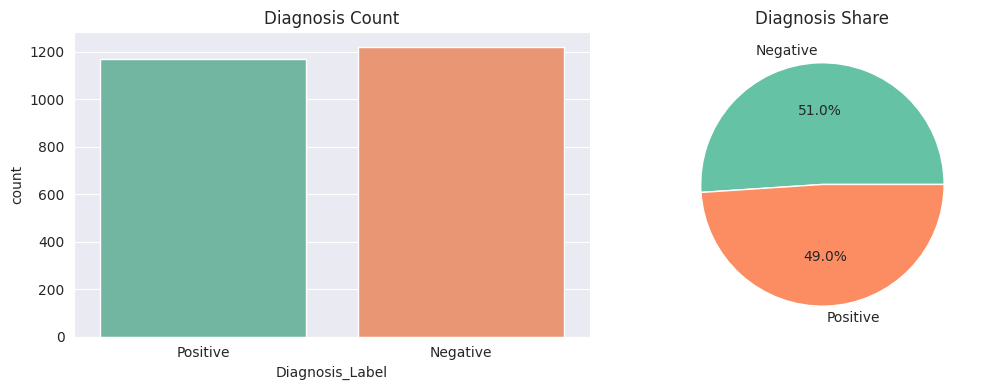

Diagnosis_Label
Negative    1221
Positive    1171
Name: count, dtype: int64
Diagnosis_Label
Negative    51.05
Positive    48.95
Name: proportion, dtype: float64


In [2]:
diag_counts = df['Diagnosis_Label'].value_counts()
diag_pct = df['Diagnosis_Label'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x='Diagnosis_Label', hue='Diagnosis_Label', palette='Set2', legend=False, ax=ax[0])
ax[0].set_title('Diagnosis Count')
ax[1].pie(diag_counts, labels=diag_counts.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
ax[1].set_title('Diagnosis Share')
plt.tight_layout()
plt.show()

print(diag_counts)
print(diag_pct.round(2))


> **Important:** the classes are heavily imbalanced (~5% positive). This has direct
> consequences for the Machine Learning notebook — accuracy alone will be a misleading metric,
> and we'll need class-weighting or resampling.

## 3. Demographics

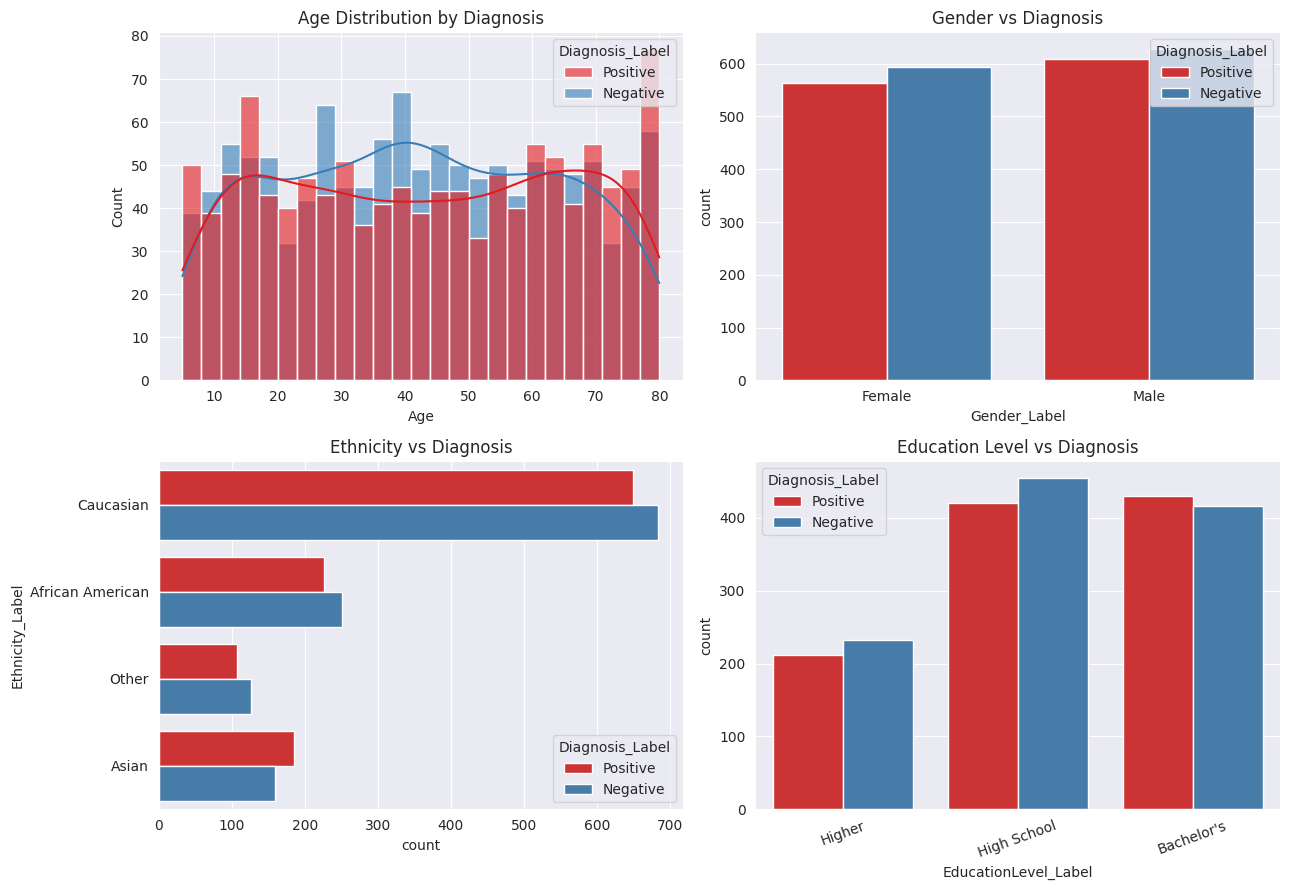

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(data=df, x='Age', hue='Diagnosis_Label', kde=True, bins=25, ax=axes[0,0], palette='Set1', alpha=0.6)
axes[0,0].set_title('Age Distribution by Diagnosis')

sns.countplot(data=df, x='Gender_Label', hue='Diagnosis_Label', ax=axes[0,1], palette='Set1')
axes[0,1].set_title('Gender vs Diagnosis')

sns.countplot(data=df, y='Ethnicity_Label', hue='Diagnosis_Label', ax=axes[1,0], palette='Set1')
axes[1,0].set_title('Ethnicity vs Diagnosis')

sns.countplot(data=df, x='EducationLevel_Label', hue='Diagnosis_Label', ax=axes[1,1], palette='Set1')
axes[1,1].set_title('Education Level vs Diagnosis')
axes[1,1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


In [4]:
age_group_rate = df.groupby('AgeGroup')['Diagnosis'].mean().sort_index()
print("Diagnosis rate by age group:")
print((age_group_rate * 100).round(2).astype(str) + '%')


Diagnosis rate by age group:
AgeGroup
0-17 (Child)    51.64%
18-29           46.77%
30-44           44.54%
45-59           46.78%
60+             52.96%
Name: Diagnosis, dtype: str


## 4. Lifestyle factors

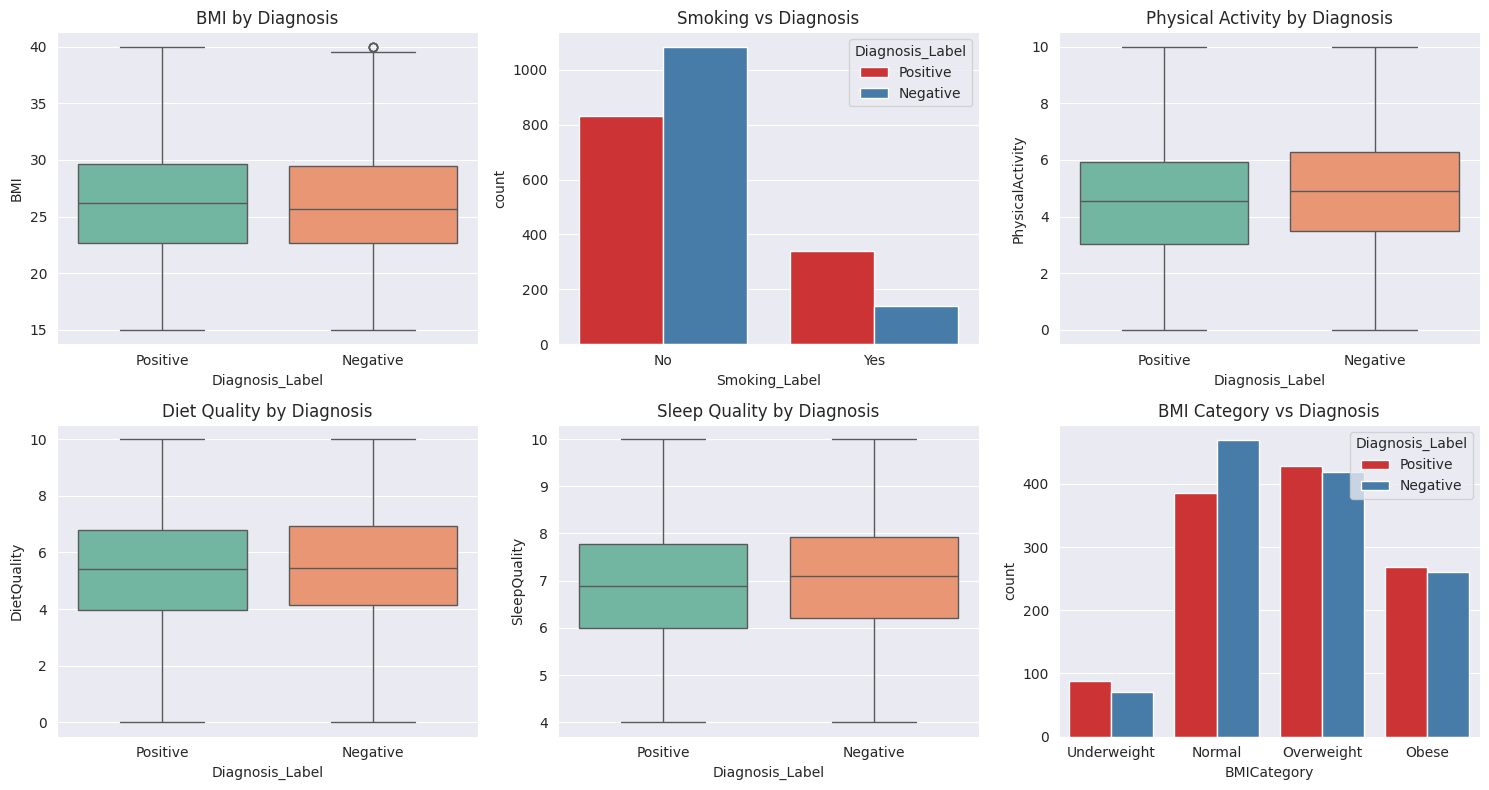

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.boxplot(data=df, x='Diagnosis_Label', y='BMI', hue='Diagnosis_Label', palette='Set2', legend=False, ax=axes[0,0])
axes[0,0].set_title('BMI by Diagnosis')

sns.countplot(data=df, x='Smoking_Label', hue='Diagnosis_Label', palette='Set1', ax=axes[0,1])
axes[0,1].set_title('Smoking vs Diagnosis')

sns.boxplot(data=df, x='Diagnosis_Label', y='PhysicalActivity', hue='Diagnosis_Label', palette='Set2', legend=False, ax=axes[0,2])
axes[0,2].set_title('Physical Activity by Diagnosis')

sns.boxplot(data=df, x='Diagnosis_Label', y='DietQuality', hue='Diagnosis_Label', palette='Set2', legend=False, ax=axes[1,0])
axes[1,0].set_title('Diet Quality by Diagnosis')

sns.boxplot(data=df, x='Diagnosis_Label', y='SleepQuality', hue='Diagnosis_Label', palette='Set2', legend=False, ax=axes[1,1])
axes[1,1].set_title('Sleep Quality by Diagnosis')

sns.countplot(data=df, x='BMICategory', hue='Diagnosis_Label', palette='Set1', ax=axes[1,2],
              order=['Underweight','Normal','Overweight','Obese'])
axes[1,2].set_title('BMI Category vs Diagnosis')

plt.tight_layout()
plt.show()


## 5. Environmental & allergy factors

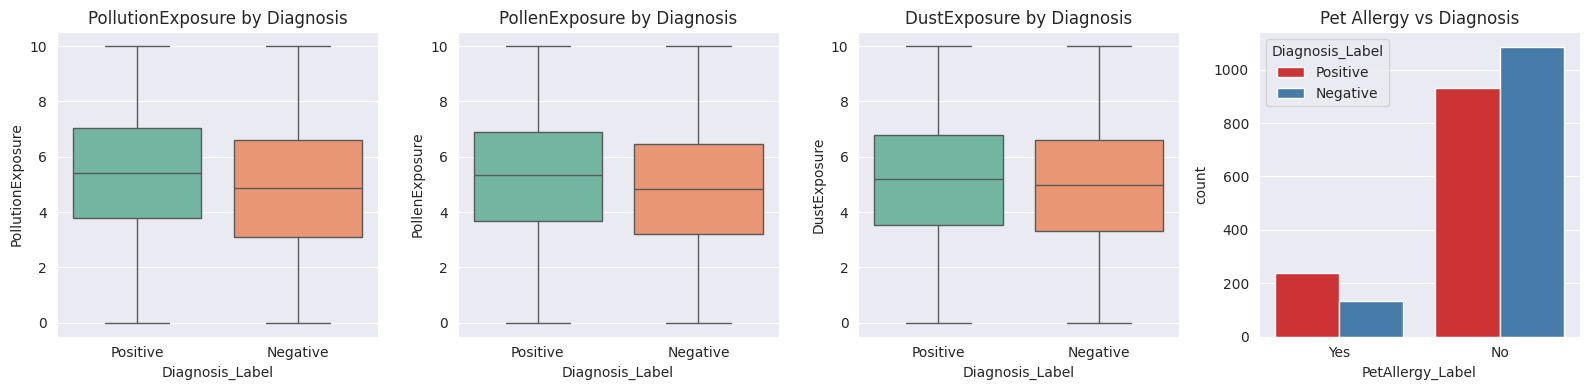

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes[:3], ['PollutionExposure', 'PollenExposure', 'DustExposure']):
    sns.boxplot(data=df, x='Diagnosis_Label', y=col, hue='Diagnosis_Label', palette='Set2', legend=False, ax=ax)
    ax.set_title(f'{col} by Diagnosis')

sns.countplot(data=df, x='PetAllergy_Label', hue='Diagnosis_Label', palette='Set1', ax=axes[3])
axes[3].set_title('Pet Allergy vs Diagnosis')

plt.tight_layout()
plt.show()


## 6. Medical history & risk factors

In [7]:
risk_cols = ['FamilyHistoryAsthma', 'HistoryOfAllergies', 'Eczema', 'HayFever', 'GastroesophagealReflux']
risk_rate = pd.DataFrame({
    'Risk Factor': risk_cols,
    'Prevalence (%)': [df[c].mean() * 100 for c in risk_cols],
    'Diagnosis Rate if Present (%)': [df.loc[df[c] == 1, 'Diagnosis'].mean() * 100 for c in risk_cols],
    'Diagnosis Rate if Absent (%)': [df.loc[df[c] == 0, 'Diagnosis'].mean() * 100 for c in risk_cols],
}).round(2)
risk_rate


,Risk Factor,Prevalence (%),Diagnosis Rate if Present (%),Diagnosis Rate if Absent (%)
0,FamilyHistoryAsthma,17.14,64.39,45.76
1,HistoryOfAllergies,32.86,64.76,41.22
2,Eczema,20.03,62.21,45.64
3,HayFever,24.08,60.94,45.15
4,GastroesophagealReflux,13.84,60.73,47.06


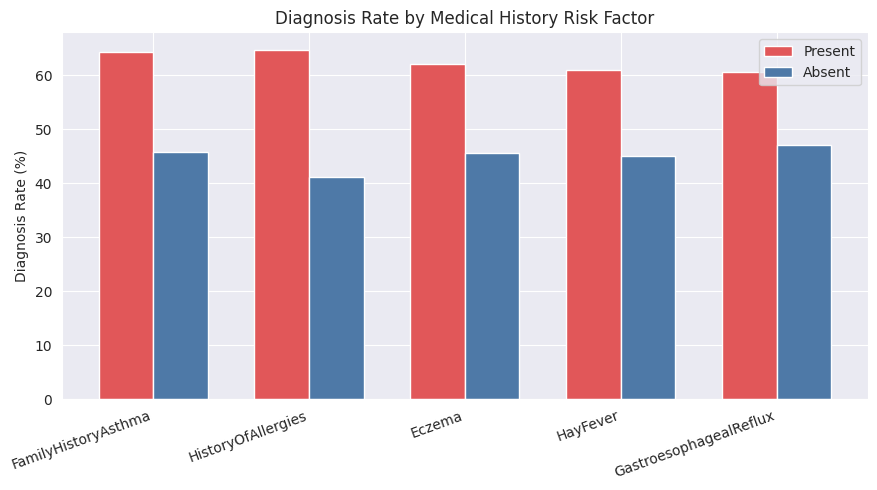

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(risk_cols))
w = 0.35
ax.bar(x - w/2, risk_rate['Diagnosis Rate if Present (%)'], width=w, label='Present', color='#e15759')
ax.bar(x + w/2, risk_rate['Diagnosis Rate if Absent (%)'], width=w, label='Absent', color='#4e79a7')
ax.set_xticks(x); ax.set_xticklabels(risk_cols, rotation=20, ha='right')
ax.set_ylabel('Diagnosis Rate (%)')
ax.set_title('Diagnosis Rate by Medical History Risk Factor')
ax.legend()
plt.tight_layout()
plt.show()


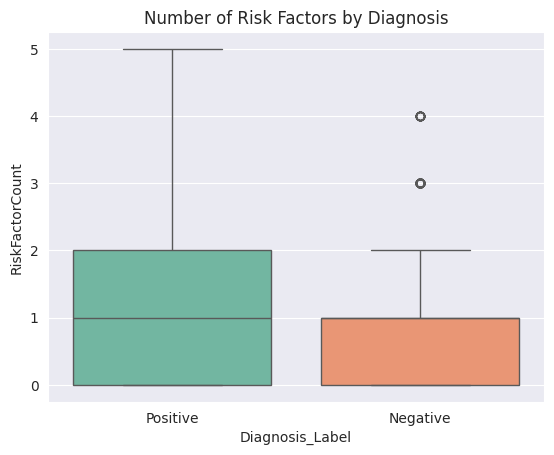

In [9]:
sns.boxplot(data=df, x='Diagnosis_Label', y='RiskFactorCount', hue='Diagnosis_Label', palette='Set2', legend=False)
plt.title('Number of Risk Factors by Diagnosis')
plt.show()


## 7. Clinical measurements — lung function

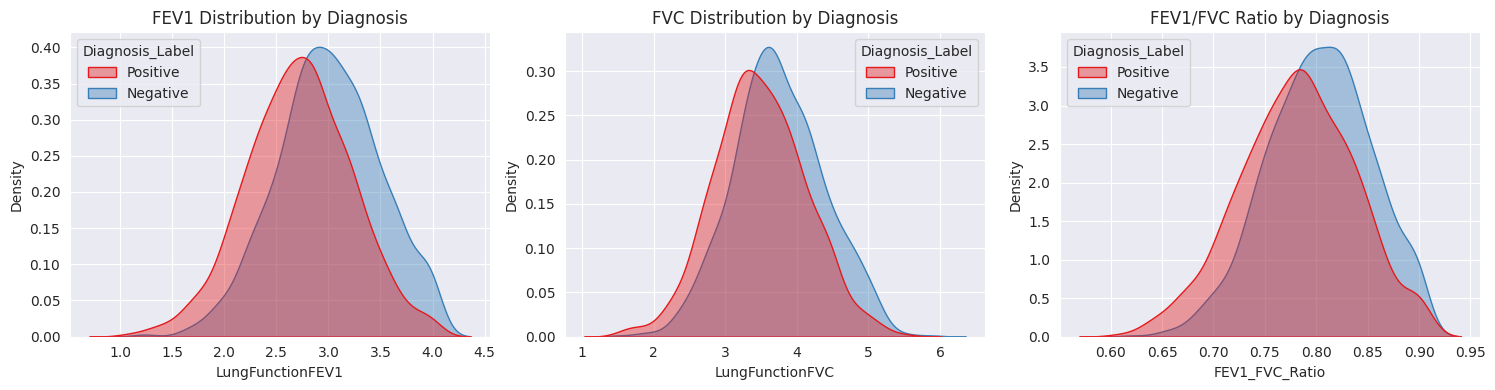

                 LungFunctionFEV1  LungFunctionFVC  FEV1_FVC_Ratio
Diagnosis_Label                                                   
Negative                    3.000            3.747           0.803
Positive                    2.716            3.487           0.781


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.kdeplot(data=df, x='LungFunctionFEV1', hue='Diagnosis_Label', fill=True, alpha=0.4, ax=axes[0], palette='Set1')
axes[0].set_title('FEV1 Distribution by Diagnosis')

sns.kdeplot(data=df, x='LungFunctionFVC', hue='Diagnosis_Label', fill=True, alpha=0.4, ax=axes[1], palette='Set1')
axes[1].set_title('FVC Distribution by Diagnosis')

sns.kdeplot(data=df, x='FEV1_FVC_Ratio', hue='Diagnosis_Label', fill=True, alpha=0.4, ax=axes[2], palette='Set1')
axes[2].set_title('FEV1/FVC Ratio by Diagnosis')

plt.tight_layout()
plt.show()

print(df.groupby('Diagnosis_Label')[['LungFunctionFEV1','LungFunctionFVC','FEV1_FVC_Ratio']].mean().round(3))


## 8. Symptoms

In [11]:
symptom_cols = ['Wheezing', 'ShortnessOfBreath', 'ChestTightness', 'Coughing',
                'NighttimeSymptoms', 'ExerciseInduced']
symptom_rate = pd.DataFrame({
    'Symptom': symptom_cols,
    'Prevalence (%)': [df[c].mean() * 100 for c in symptom_cols],
    'Diagnosis Rate if Present (%)': [df.loc[df[c] == 1, 'Diagnosis'].mean() * 100 for c in symptom_cols],
}).round(2).sort_values('Diagnosis Rate if Present (%)', ascending=False)
symptom_rate


,Symptom,Prevalence (%),Diagnosis Rate if Present (%)
0,Wheezing,39.67,67.12
2,ChestTightness,35.16,66.35
1,ShortnessOfBreath,40.47,66.01
4,NighttimeSymptoms,35.87,65.03
5,ExerciseInduced,40.93,64.45
3,Coughing,46.49,60.61


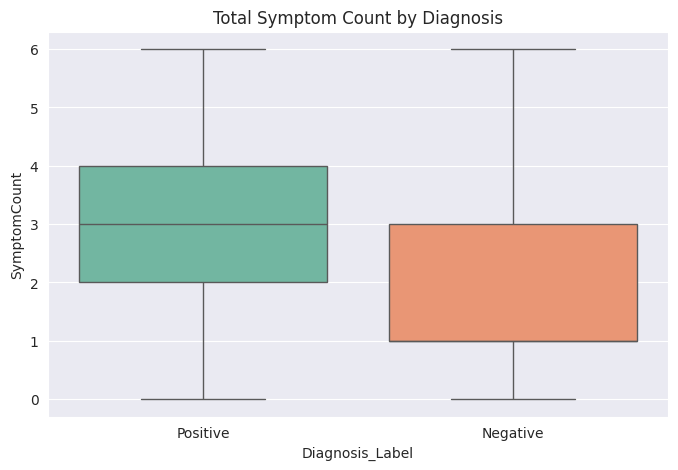

                  count  mean   std  min  25%  50%  75%  max
Diagnosis_Label                                             
Negative         1221.0  1.65  1.28  0.0  1.0  1.0  3.0  6.0
Positive         1171.0  3.16  1.54  0.0  2.0  3.0  4.0  6.0


In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Diagnosis_Label', y='SymptomCount', hue='Diagnosis_Label', palette='Set2', legend=False)
plt.title('Total Symptom Count by Diagnosis')
plt.show()

print(df.groupby('Diagnosis_Label')['SymptomCount'].describe().round(2))


## 9. Correlation analysis

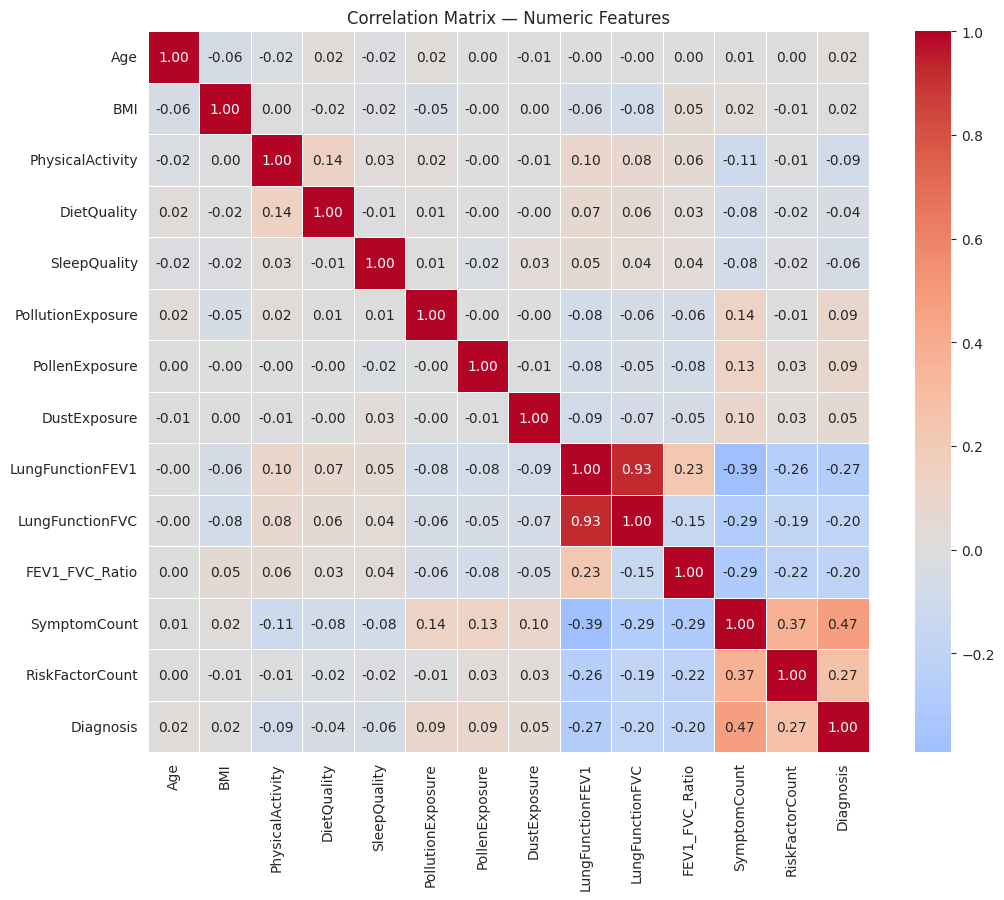

In [13]:
numeric_cols = ['Age','BMI','PhysicalActivity','DietQuality','SleepQuality','PollutionExposure',
                'PollenExposure','DustExposure','LungFunctionFEV1','LungFunctionFVC','FEV1_FVC_Ratio',
                'SymptomCount','RiskFactorCount','Diagnosis']

corr = df[numeric_cols].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()


In [14]:
corr_with_target = corr['Diagnosis'].drop('Diagnosis').sort_values(key=abs, ascending=False)
print("Correlation of each numeric feature with Diagnosis (sorted by strength):")
print(corr_with_target.round(3))


Correlation of each numeric feature with Diagnosis (sorted by strength):
SymptomCount         0.472
LungFunctionFEV1    -0.274
RiskFactorCount      0.270
FEV1_FVC_Ratio      -0.204
LungFunctionFVC     -0.199
PollutionExposure    0.092
PollenExposure       0.092
PhysicalActivity    -0.091
SleepQuality        -0.058
DustExposure         0.049
DietQuality         -0.041
Age                  0.022
BMI                  0.016
Name: Diagnosis, dtype: float64


> This dataset shows real, clinically plausible signal: `SymptomCount` correlates with Diagnosis at 0.47, and lung-function measures (`LungFunctionFEV1`, `FEV1_FVC_Ratio`, `LungFunctionFVC`) all show moderate negative correlation, consistent with worse lung function accompanying a positive diagnosis. This is a meaningfully stronger and more realistic signal than a typical purely-synthetic dataset, and it's confirmed by the formal tests below.


## 10. Statistical tests — which features actually differ by diagnosis?

In [15]:
print("=== T-tests: numeric feature means, Positive vs Negative diagnosis ===\n")
results = []
for col in numeric_cols[:-1]:
    pos = df.loc[df['Diagnosis'] == 1, col]
    neg = df.loc[df['Diagnosis'] == 0, col]
    t_stat, p_val = stats.ttest_ind(pos, neg, equal_var=False)
    results.append((col, pos.mean(), neg.mean(), t_stat, p_val))

ttest_df = pd.DataFrame(results, columns=['Feature','Mean (Positive)','Mean (Negative)','t-stat','p-value'])
ttest_df['Significant (p<0.05)'] = ttest_df['p-value'] < 0.05
ttest_df.sort_values('p-value')


=== T-tests: numeric feature means, Positive vs Negative diagnosis ===



,Feature,Mean (Positive),Mean (Negative),t-stat,p-value,Significant (p<0.05)
11,SymptomCount,3.157131,1.646192,26.044791,3.918902e-131,True
8,LungFunctionFEV1,2.716140,2.999975,-13.905535,2.533798e-42,True
12,RiskFactorCount,1.385995,0.785422,13.655683,7.786330e-41,True
10,FEV1_FVC_Ratio,0.780623,0.802752,-10.174683,7.988150e-24,True
9,LungFunctionFVC,3.486857,3.746601,-9.933210,8.229160e-23,True
5,PollutionExposure,5.329752,4.878452,4.527065,6.274191e-06,True
6,PollenExposure,5.284295,4.848640,4.522090,6.422463e-06,True
2,PhysicalActivity,4.541059,4.938280,-4.463109,8.453246e-06,True
4,SleepQuality,6.912639,7.062400,-2.854144,4.352570e-03,True
7,DustExposure,5.187899,4.950385,2.421554,1.552860e-02,True


In [16]:
print("=== Chi-square tests: categorical features vs Diagnosis ===\n")
cat_cols = ['Gender_Label','Ethnicity_Label','EducationLevel_Label','Smoking_Label','PetAllergy_Label',
            'FamilyHistoryAsthma_Label','HistoryOfAllergies_Label','Eczema_Label','HayFever_Label',
            'GastroesophagealReflux_Label','Wheezing_Label','ShortnessOfBreath_Label','ChestTightness_Label',
            'Coughing_Label','NighttimeSymptoms_Label','ExerciseInduced_Label','AgeGroup','BMICategory']

chi_results = []
for col in cat_cols:
    table = pd.crosstab(df[col], df['Diagnosis'])
    chi2, p, dof, _ = stats.chi2_contingency(table)
    chi_results.append((col, chi2, p))

chi_df = pd.DataFrame(chi_results, columns=['Feature','Chi2','p-value'])
chi_df['Significant (p<0.05)'] = chi_df['p-value'] < 0.05
chi_df.sort_values('p-value')


=== Chi-square tests: categorical features vs Diagnosis ===



,Feature,Chi2,p-value,Significant (p<0.05)
10,Wheezing_Label,206.596776,7.592435e-47,True
11,ShortnessOfBreath_Label,188.180789,7.932960e-43,True
15,ExerciseInduced_Label,158.260903,2.714143e-36,True
12,ChestTightness_Label,155.975703,8.569923e-36,True
14,NighttimeSymptoms_Label,137.435112,9.685706e-32,True
3,Smoking_Label,116.442531,3.802394e-27,True
6,HistoryOfAllergies_Label,116.061125,4.608706e-27,True
13,Coughing_Label,112.123641,3.357079e-26,True
5,FamilyHistoryAsthma_Label,46.434083,9.475292e-12,True
8,HayFever_Label,42.964345,5.574664e-11,True


## 11. Key insights summary

In [17]:
n_sig_numeric = ttest_df['Significant (p<0.05)'].sum()
n_sig_cat = chi_df['Significant (p<0.05)'].sum()

print(f"Total patients: {len(df):,}")
print(f"Diagnosis positive rate: {df['Diagnosis'].mean()*100:.2f}%")
print(f"Numeric features statistically associated with diagnosis (t-test, p<0.05): {n_sig_numeric} / {len(ttest_df)}")
print(f"Categorical features statistically associated with diagnosis (chi-square, p<0.05): {n_sig_cat} / {len(chi_df)}")
print()
print("Top numeric features by statistical strength:")
print(ttest_df.sort_values('p-value').head(5)[['Feature','p-value']].to_string(index=False))
print()
print("Top categorical features by statistical strength:")
print(chi_df.sort_values('p-value').head(5)[['Feature','p-value']].to_string(index=False))


Total patients: 2,392
Diagnosis positive rate: 48.95%
Numeric features statistically associated with diagnosis (t-test, p<0.05): 11 / 13
Categorical features statistically associated with diagnosis (chi-square, p<0.05): 15 / 18

Top numeric features by statistical strength:
         Feature       p-value
    SymptomCount 3.918902e-131
LungFunctionFEV1  2.533798e-42
 RiskFactorCount  7.786330e-41
  FEV1_FVC_Ratio  7.988150e-24
 LungFunctionFVC  8.229160e-23

Top categorical features by statistical strength:
                Feature      p-value
         Wheezing_Label 7.592435e-47
ShortnessOfBreath_Label 7.932960e-43
  ExerciseInduced_Label 2.714143e-36
   ChestTightness_Label 8.569923e-36
NighttimeSymptoms_Label 9.685706e-32


### Takeaways for the Machine Learning notebook (`04_Machine_Learning.ipynb`)

- **The diagnosis rate is close to balanced (~49% positive)**, so severe class-imbalance handling (heavy reweighting/SMOTE) is far less critical here than in a rare-event problem — we'll still use `class_weight='balanced'` for consistency, but it isn't doing the heavy lifting.
- **Strong, learnable signal exists**: 11 of 13 numeric features and 15 of 18 categorical features are statistically associated with Diagnosis (p < 0.05). `SymptomCount`, lung-function measures, `RiskFactorCount`, smoking, and allergy history are the standout predictors.
- Both linear (Logistic Regression) and non-linear (Random Forest, XGBoost) models should be able to pick up this signal — worth comparing rather than assuming tree-based models will dominate.
- Feature engineering from cleaning (`SymptomCount`, `RiskFactorCount`, `FEV1_FVC_Ratio`, `AgeGroup`, `BMICategory`) is retained as candidate model inputs alongside the raw fields.
